In [1]:
import os
import time
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))
import MGLensing
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.special import factorial
from scipy import integrate
from copy import deepcopy



# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

euclidlib not installed! Euclid TR1 setup will not be available!
/Users/s2265800/Desktop/GitHub/MGlensing/MGLensing


In [2]:
# switch to the main directory
os.chdir('/Users/s2265800/Desktop/GitHub/MGlensing')

# Survey
LSST Y1 setup

In [3]:
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

In [4]:
MGL = MGLensing.MGL("ini_files/config_files/config_hmcode.yaml")
zz = MGL.Survey.zz_integr
nbin = MGL.Survey.nbin_s


l_wl_max, l_gc_max = MGL.Survey.ells_wl_max, MGL.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL.Survey.l_wl, MGL.Survey.l_gc, MGL.Survey.l_xc

Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  0
initialising hmcode
Zennaro 2024 cross-sqrt-bar boost is applied with self.flag_cross_sqrt_bar_boost:  False
################################
checking parameters for data....
all good with the data dictionary
################################
start c

In [5]:
params = {
    'Omega_m' :  0.315,
    'Omega_c' :  0.315-0.05,
    'Omega_cb' :  0.315,
    'Omega_nu':  0.,
    'As'      :  np.exp(3.07)*1.e-10,
    'Omega_b' :  0.05,
    'ns'      :  0.96,
    'h'       :  0.67,
    'Mnu'     :  0.0,
    'w0'      :  -1.0,
    'wa'      :  0.0,
    'a1_IA': 0.16,
    'eta1_IA': 1.66,
    'beta_IA': 0.,
}

b0 = 0.68
bias1_arr = np.array([b0*(1.+z_bin_center_i) for z_bin_center_i in MGL.Survey.z_bin_center_l ])
for bin_i in range(nbin):
    params[f'b1_{bin_i+1}']=bias1_arr[bin_i]

This notebook demonstrates differences between MG emulators trained on power spectra from simulations (ext-emu) and analytical ReACT computations. All ReACT-based emulators were trained with CosmoPower, which allows for batch evaluations (i.e., simulateneously produce power spectra for an array of cosmological parameters/redshifts), while ext-emus do not have this property and must be called in a loop.

In [7]:
# first call MGL
NL_MODEL_HMCODE = 0
NL_MODEL_BACCO = 1
NL_MODEL_NDGP = 2
NL_MODEL_GAMMAZ = 3
NL_MODEL_MUSIGMA = 4
NL_MODEL_DS = 5
NL_MODEL_FOFR = 6
NL_MODEL_FOFR_EMANTIS = 7
NL_MODEL_NDGP_EMU = 8
NL_MODEL_MUKZ = 9

models_gr =     {'GR_nonlin': {'nl_model': NL_MODEL_HMCODE, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
                'GR_lin': {'nl_model': NL_MODEL_HMCODE, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},}

models_ndgp = {
    'react_nonlin': {'nl_model': NL_MODEL_NDGP, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'react_lin': {'nl_model': NL_MODEL_NDGP, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'ext_nonlin': {'nl_model': NL_MODEL_NDGP_EMU, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'ext_lin': {'nl_model': NL_MODEL_NDGP_EMU, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    
    }

models_fofr = {
    'react_nonlin': {'nl_model': NL_MODEL_FOFR, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'react_lin': {'nl_model': NL_MODEL_FOFR, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},

    'ext_nonlin': {'nl_model': NL_MODEL_FOFR_EMANTIS, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'ext_lin': {'nl_model': NL_MODEL_FOFR_EMANTIS, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    
    }

# nDGP comparison
To install nDGPemu follow the installation steps here: https://github.com/BartolomeoF/nDGPemu/tree/main

In [8]:
power_spectra_gr = {}
for model_opt in models_gr:
    try:
        k_ell, pmm, pgm, pgg = MGL.get_power_spectra(params, models_gr[model_opt])
        print(f"Model: {model_opt}, k_ell shape: {k_ell.shape}, pmm shape: {pmm.shape}, pgm shape: {pgm.shape}, pgg shape: {pgg.shape}")
        power_spectra_gr[model_opt] = {
            'k': k_ell,
            'pmm': pmm,
        }
    except ValueError as e:
        print(f"Error with model {model_opt}: {e}")

model["nl_model"] =  0
initialising hmcode
Model: GR_nonlin, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)
model["nl_model"] =  0
initialising hmcode
Model: GR_lin, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)


In [9]:
import warnings
from sklearn.exceptions import InconsistentVersionWarning

warnings.filterwarnings(
    "ignore",
    category=InconsistentVersionWarning,
)

log10Omega_rc_arr = [np.log10(0.25), np.log10(1.2),  np.log10(6.1)]

power_spectra_ndgp = {}
for model_opt in models_ndgp:
        for i in range(len(log10Omega_rc_arr)):
            params_ndgp = params.copy()
            params_ndgp['log10Omega_rc'] = log10Omega_rc_arr[i] 
            k_ell, pmm, pgm, pgg = MGL.get_power_spectra(params_ndgp, models_ndgp[model_opt])
            power_spectra_ndgp[model_opt+str(i+1)] = {
                'k': k_ell,
                'pmm': pmm,
            }

model["nl_model"] =  2
initialising nDGP ReACT
model["nl_model"] =  2
initialising nDGP ReACT
model["nl_model"] =  2
initialising nDGP ReACT
model["nl_model"] =  2
initialising nDGP ReACT
model["nl_model"] =  2
initialising nDGP ReACT
model["nl_model"] =  2
initialising nDGP ReACT
model["nl_model"] =  8
initialising nDGP emulator
Loading model and related data
model["nl_model"] =  8
initialising nDGP emulator
Loading model and related data
model["nl_model"] =  8
initialising nDGP emulator
Loading model and related data
model["nl_model"] =  8
initialising nDGP emulator
Loading model and related data
model["nl_model"] =  8
initialising nDGP emulator
Loading model and related data
model["nl_model"] =  8
initialising nDGP emulator
Loading model and related data


In [10]:
_, rcom = MGL.get_expansion_and_rcom(params)
# pick 3 redshifts
z_int_pick = [40, 120, 170] #goes from 0 to 255
def k2ell(x, ind=z_int_pick[0]):
    return x*rcom[ind]-0.5
def ell2k(x, ind=z_int_pick[0]):
    return (x+0.5)/rcom[ind]
def k2ell1(x, ind=z_int_pick[1]):
    return x*rcom[ind]-0.5
def ell2k1(x, ind=z_int_pick[1]):
    return (x+0.5)/rcom[ind]
def k2ell2(x, ind=z_int_pick[2]):
    return x*rcom[ind]-0.5
def ell2k2(x, ind=z_int_pick[2]):
    return (x+0.5)/rcom[ind]
f_arr = [k2ell, k2ell1, k2ell2]
f_inv_arr = [ell2k, ell2k1, ell2k2]
# pick the bins
bin_i=2
bin_j=3

In [11]:
colors = sns.color_palette("Paired")
model_opt_nonlin = ['react_nonlin', 'ext_nonlin']
model_opt_lin = ['react_lin', 'ext_lin']
labels = ['ReACT: $\Omega_{rc}=0.25$', 'ReACT: $\Omega_{rc}=1.2$', 'ReACT: $\Omega_{rc}=6.1$',  'EMU: $\Omega_{rc}=0.25$', 'EMU: $\Omega_{rc}=1.2$', 'EMU: $\Omega_{rc}=6.1$', ]


  ax[0][i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='upper left', frameon=True, title_fontsize=20)



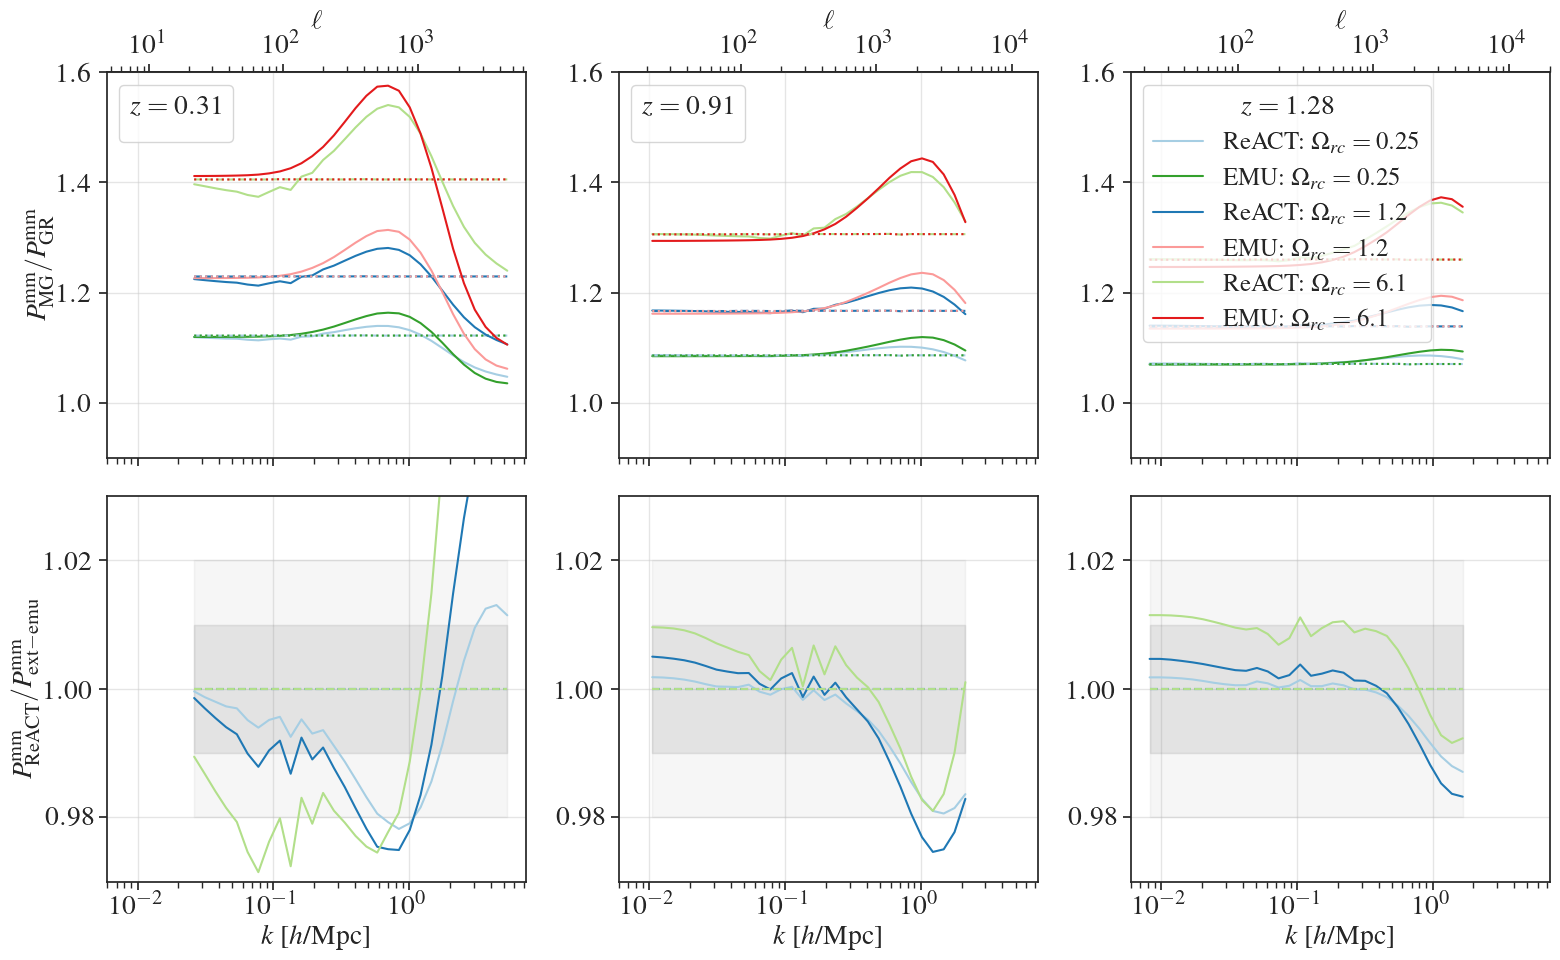

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(16, 10), facecolor='w', gridspec_kw={'height_ratios':[1,1] }, sharex=True)
pmm_gr_nl = power_spectra_gr['GR_nonlin']['pmm']
pmm_gr_lin = power_spectra_gr['GR_lin']['pmm']
for i in range(3):
    for num in range(len(log10Omega_rc_arr)):
        k_ell = power_spectra_ndgp['react_nonlin'+str(num+1)]['k']
        pmm = power_spectra_ndgp['react_nonlin'+str(num+1)]['pmm']
        ax[0][i].semilogx(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]]/pmm_gr_nl[:, z_int_pick[i]], linewidth=1.5, color = colors[num], label=labels[num] if i == 2 else '')
        pmm_ext = power_spectra_ndgp['ext_nonlin'+str(num+1)]['pmm']
        ax[0][i].semilogx(k_ell[:, z_int_pick[i]], pmm_ext[:, z_int_pick[i]]/pmm_gr_nl[:, z_int_pick[i]], linewidth=1.5, color = colors[num+3], label=labels[num+3] if i == 2 else '')

        ax[1][i].semilogx(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]]/pmm_ext[:, z_int_pick[i]], linewidth=1.5)#, color = colors[num])


        pmm_lin = power_spectra_ndgp['react_lin'+str(num+1)]['pmm']
        ax[0][i].semilogx(k_ell[:, z_int_pick[i]], pmm_lin[:, z_int_pick[i]]/pmm_gr_lin[:, z_int_pick[i]], linewidth=1.5, color = colors[num], linestyle='--')
        pmm_ext_lin = power_spectra_ndgp['ext_lin'+str(num+1)]['pmm']
        ax[0][i].semilogx(k_ell[:, z_int_pick[i]], pmm_ext_lin[:, z_int_pick[i]]/pmm_gr_lin[:, z_int_pick[i]], linewidth=1.5, color = colors[num+3], linestyle=':')

        ax[1][i].semilogx(k_ell[:, z_int_pick[i]], pmm_lin[:, z_int_pick[i]]/pmm_ext_lin[:, z_int_pick[i]], linewidth=1.5, color = colors[num], linestyle='--')
        ax[1][i].fill_between(k_ell[:, z_int_pick[i]], np.ones(len(k_ell[:, z_int_pick[i]]))*0.99, np.ones(len(k_ell[:, z_int_pick[i]]))*1.01, color='tab:grey', alpha=0.05)
        ax[1][i].fill_between(k_ell[:, z_int_pick[i]], np.ones(len(k_ell[:, z_int_pick[i]]))*0.98, np.ones(len(k_ell[:, z_int_pick[i]]))*1.02, color='tab:grey', alpha=0.02)

    ax[0][i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='upper left', frameon=True, title_fontsize=20)
    ax[1][i].set_xlabel("$k$ [$h$/Mpc]")
    secax = ax[0][i].secondary_xaxis('top', functions=(f_arr[i], f_inv_arr[i]))
    secax.set_xlabel('$\ell$')
    ax[0][i].grid(alpha=0.5)
    ax[1][i].grid(alpha=0.5)
    ax[0][i].set_ylim(0.9, 1.6)    
    ax[1][i].set_ylim(0.97, 1.03)   
    #ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
ax[0][0].set_ylabel("$P^{\\rm mm}_{\\rm MG}/P_{\\rm GR}^{\\rm mm}$")
ax[1][0].set_ylabel("$P^{\\rm mm}_{\\rm ReACT}/P^{\\rm mm}_{\\rm ext-emu}$")
plt.tight_layout()

In [14]:
ang_power_spectra_gr = {}
for model_opt in models_gr:
    try:
        cl_ll_mgl, cl_gg_mgl, cl_lg_mgl, cl_gl_mgl =  MGL.get_c_ells(params, models_gr[model_opt])
        print(f"Model: {model_opt}, cl_ll_mgl shape: {cl_ll_mgl.shape}, cl_gg_mgl shape: {cl_gg_mgl.shape}, cl_lg_mgl shape: {cl_lg_mgl.shape}, cl_gl_mgl shape: {cl_gl_mgl.shape}")
        ang_power_spectra_gr[model_opt] = {
            'wl': cl_ll_mgl,
            'gc': cl_gg_mgl,
            'xc': cl_gl_mgl
        }
    except ValueError as e:
        print(f"Error with model {model_opt}: {e}")

model["nl_model"] =  0
initialising hmcode
Theo model:  {'nl_model': 0, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: GR_nonlin, cl_ll_mgl shape: (30, 5, 5), cl_gg_mgl shape: (30, 5, 5), cl_lg_mgl shape: (30, 5, 5), cl_gl_mgl shape: (30, 5, 5)
model["nl_model"] =  0
initialising hmcode
Theo model:  {'nl_model': 0, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: GR_lin, cl_ll_mgl shape: (30, 5, 5), cl_gg_mgl shape: (30, 5, 5), cl_lg_mgl shape: (30, 5, 5), cl_gl_mgl shape: (30, 5, 5)


In [15]:
ang_power_spectra_ndgp = {}
for model_opt in models_ndgp:
        for i in range(len(log10Omega_rc_arr)):
            params_ndgp = params.copy()
            params_ndgp['log10Omega_rc'] = log10Omega_rc_arr[i] 
            cl_ll_mgl, cl_gg_mgl, cl_lg_mgl, cl_gl_mgl =  MGL.get_c_ells(params_ndgp, models_ndgp[model_opt])
            print(f"Model: {model_opt}, cl_ll_mgl shape: {cl_ll_mgl.shape}, cl_gg_mgl shape: {cl_gg_mgl.shape}, cl_lg_mgl shape: {cl_lg_mgl.shape}, cl_gl_mgl shape: {cl_gl_mgl.shape}")
            ang_power_spectra_ndgp[model_opt+str(i+1)] = {
                'wl': cl_ll_mgl,
                'gc': cl_gg_mgl,
                'xc': cl_gl_mgl
            }

model["nl_model"] =  2
initialising nDGP ReACT
Theo model:  {'nl_model': 2, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: react_nonlin, cl_ll_mgl shape: (30, 5, 5), cl_gg_mgl shape: (30, 5, 5), cl_lg_mgl shape: (30, 5, 5), cl_gl_mgl shape: (30, 5, 5)
model["nl_model"] =  2
initialising nDGP ReACT
Theo model:  {'nl_model': 2, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: react_nonlin, cl_ll_mgl shape: (30, 5, 5), cl_gg_mgl shape: (30, 5, 5), cl_lg_mgl shape: (30, 5, 5), cl_gl_mgl shape: (30, 5, 5)
model["nl_model"] =  2
initialising nDGP ReACT
Theo model:  {'nl_model': 2, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: react_nonlin, cl_ll_mgl shape: (30, 5, 5), cl_gg_mgl shape: (30, 5, 5), cl_lg_mgl shape: (30, 5, 5), cl_gl_mgl shape: (30, 5, 5)
model["nl_model"] =  2
initialising nDGP ReACT
Theo model:  {'nl_model': 2, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_

In [16]:
err_cl_ll, err_cl_gg, err_cl_lg  = MGL.get_errorbars(params)


cov_flat:  (1650, 1650)
cov_flat_masked:  (1650, 1650)


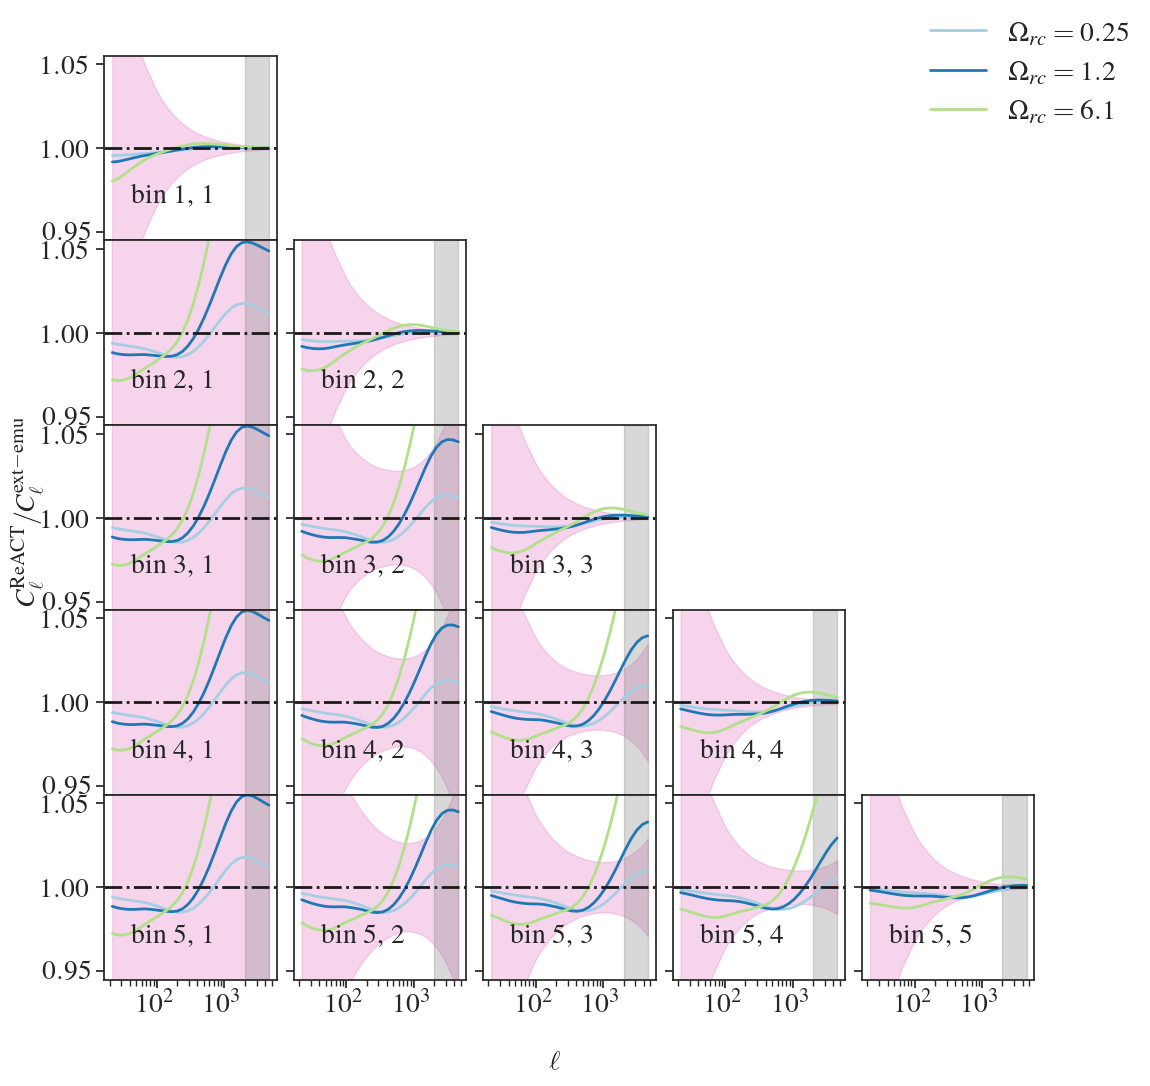

In [17]:
cell_gr_nl = ang_power_spectra_gr['GR_nonlin']['wl']
cell_gr_lin = ang_power_spectra_gr['GR_lin']['wl']
labels = ['$\Omega_{rc}=0.25$', '$\Omega_{rc}=1.2$', '$\Omega_{rc}=6.1$' ]

fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            for num in range(len(log10Omega_rc_arr)):
                cl_ll_mgl = ang_power_spectra_ndgp['react_nonlin'+str(num+1)]['wl']
                cl_ll_mgl_ext = ang_power_spectra_ndgp['ext_nonlin'+str(num+1)]['wl']
                ax[i,j].semilogx(l_wl, cl_ll_mgl[:,i,j]/cl_ll_mgl_ext[:, i, j], linewidth=2, color = colors[num])

                #cl_ll_mgl = ang_power_spectra_ndgp['react_lin'+str(num+1)]['wl']
                #cl_ll_mgl_ext = ang_power_spectra_ndgp['ext_lin'+str(num+1)]['wl']
                #ax[i,j].semilogx(l_wl, cl_ll_mgl[:,i,j]/cl_ll_mgl_ext[:, i, j], linewidth=2, color = colors[num], linestyle='--')
            cls = ang_power_spectra_ndgp['ext_nonlin1']['wl']
            err_prop = err_cl_ll[:, i, j]/cls[:, i, j]
            ax[i, j].fill_between(l_wl, np.ones(len(l_wl))+err_prop, np.ones(len(l_wl))-err_prop, color='tab:pink', alpha=0.3)
            ax[i, j].set_ylim(0.945, 1.055)
            ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes) 
            ax[i, j].axhline(y=1, linestyle='-.', linewidth=2, color='k')
            ax[i, j].axvspan(xmin=l_wl_max[i, j], xmax=l_wl[-1], color='grey', alpha=0.3)
        else:
            ax[i,j].axis('off')       
fig.text(0.06, 0.5, r'$C^{\rm ReACT}_\ell/C^{\rm ext-emu}_\ell$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend(labels, loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False)

# f(R) gravity comparison
eMANTIS is pip-installable: https://gitlab.obspm.fr/e-mantis/e-mantis

In [18]:
log10f_R0_arr = [-7., -5., -4.]

power_spectra_fofr = {}
for model_opt in models_fofr:
        for i in range(len(log10f_R0_arr)):
            params_fofr = params.copy()
            params_fofr['log10f_R0'] = log10f_R0_arr[i] 
            k_ell, pmm, pgm, pgg = MGL.get_power_spectra(params_fofr, models_fofr[model_opt])
            power_spectra_fofr[model_opt+str(i+1)] = {
                'k': k_ell,
                'pmm': pmm,
            }

model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
model["nl_model"] =  7
initialising f(R) eMANTIS
initialising hmcode
Training the emulator at aexp=1.0000... done.
Training the emulator at aexp=0.9524... done.
Training the emulator at aexp=0.9091... done.
Training the emulator at aexp=0.8696... done.
Training the emulator at aexp=0.8000... done.
Training the emulator at aexp=0.7692... done.
Training the emulator at aexp=0.7042... done.
Training the emulator at aexp=0.6667... done.
Training the emulator at aexp=0.6250... done.
Training the emulator at aexp=0.5882... done.
Training the emulator at aexp=0.5556... done.
Training the emulator a



  secax.set_xlabel('$\ell$')

  ax[0][i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='upper left', frameon=True, title_fontsize=20)



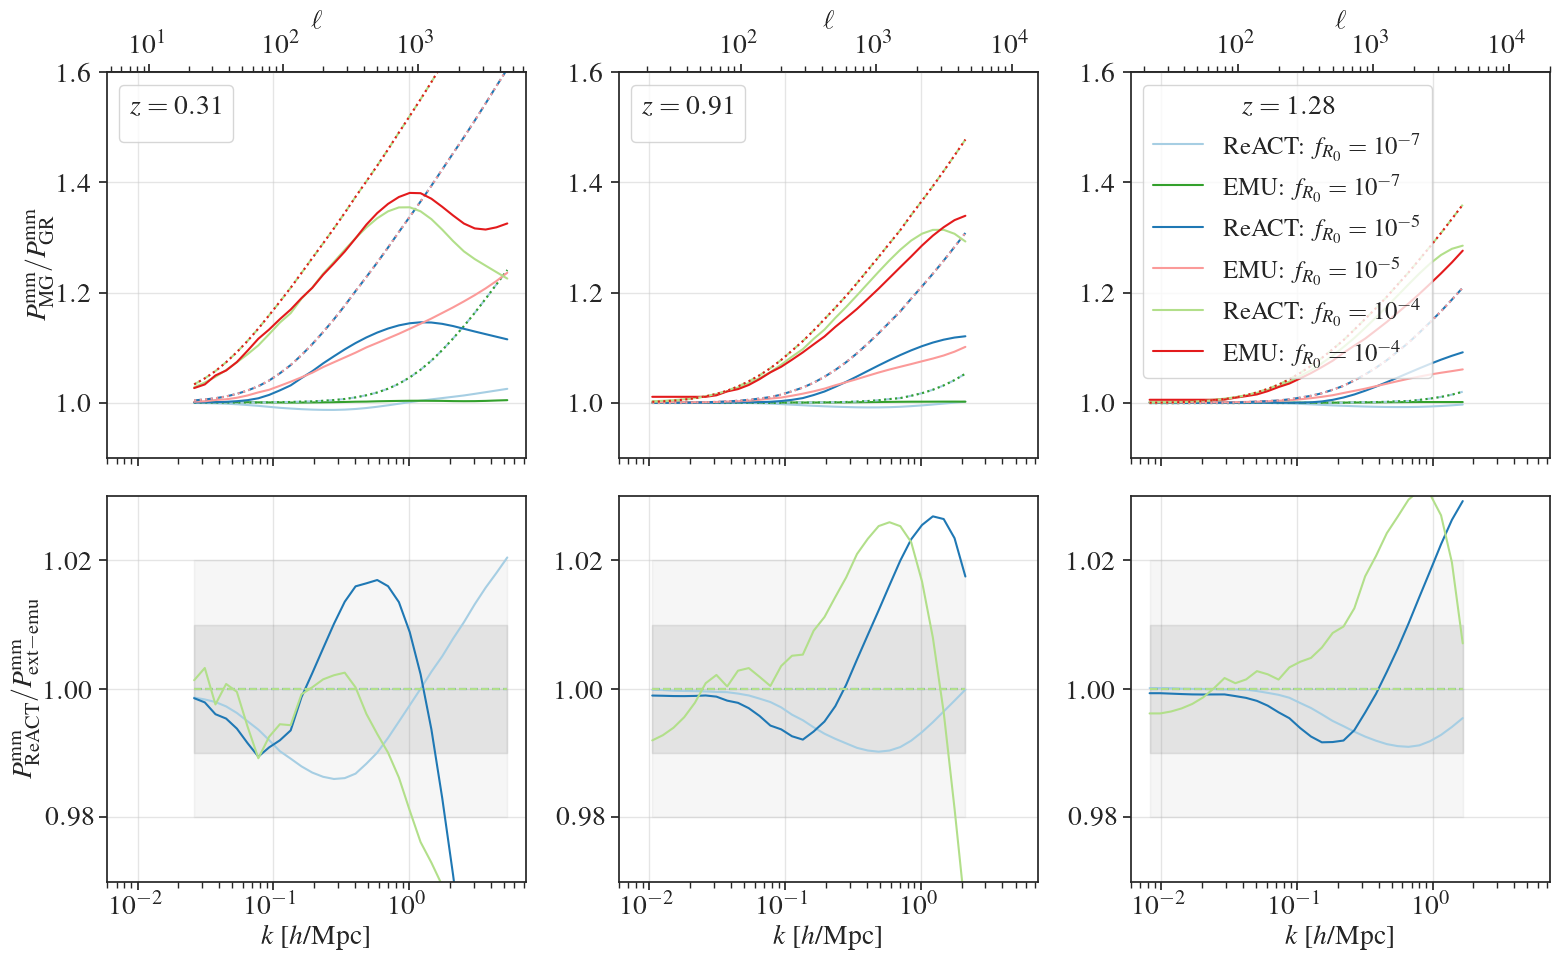

In [19]:
labels = ['ReACT: $f_{R_0}=10^{-7}$', 'ReACT: $f_{R_0}=10^{-5}$', 'ReACT: $f_{R_0}=10^{-4}$',  'EMU: $f_{R_0}=10^{-7}$', 'EMU: $f_{R_0}=10^{-5}$', 'EMU: $f_{R_0}=10^{-4}$']

fig, ax = plt.subplots(2, 3, figsize=(16, 10), facecolor='w', gridspec_kw={'height_ratios':[1,1] }, sharex=True)
pmm_gr_nl = power_spectra_gr['GR_nonlin']['pmm']
pmm_gr_lin = power_spectra_gr['GR_lin']['pmm']
for i in range(3):
    for num in range(len(log10Omega_rc_arr)):
        k_ell = power_spectra_fofr['react_nonlin'+str(num+1)]['k']
        pmm = power_spectra_fofr['react_nonlin'+str(num+1)]['pmm']
        ax[0][i].semilogx(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]]/pmm_gr_nl[:, z_int_pick[i]], linewidth=1.5, color = colors[num], label=labels[num] if i == 2 else '')
        pmm_ext = power_spectra_fofr['ext_nonlin'+str(num+1)]['pmm']
        ax[0][i].semilogx(k_ell[:, z_int_pick[i]], pmm_ext[:, z_int_pick[i]]/pmm_gr_nl[:, z_int_pick[i]], linewidth=1.5, color = colors[num+3], label=labels[num+3] if i == 2 else '')

        ax[1][i].semilogx(k_ell[:, z_int_pick[i]], pmm[:, z_int_pick[i]]/pmm_ext[:, z_int_pick[i]], linewidth=1.5)#, color = colors[num])


        pmm_lin = power_spectra_fofr['react_lin'+str(num+1)]['pmm']
        ax[0][i].semilogx(k_ell[:, z_int_pick[i]], pmm_lin[:, z_int_pick[i]]/pmm_gr_lin[:, z_int_pick[i]], linewidth=1.5, color = colors[num], linestyle='--')
        pmm_ext_lin = power_spectra_fofr['ext_lin'+str(num+1)]['pmm']
        ax[0][i].semilogx(k_ell[:, z_int_pick[i]], pmm_ext_lin[:, z_int_pick[i]]/pmm_gr_lin[:, z_int_pick[i]], linewidth=1.5, color = colors[num+3], linestyle=':')

        ax[1][i].semilogx(k_ell[:, z_int_pick[i]], pmm_lin[:, z_int_pick[i]]/pmm_ext_lin[:, z_int_pick[i]], linewidth=1.5, color = colors[num], linestyle='--')
        ax[1][i].fill_between(k_ell[:, z_int_pick[i]], np.ones(len(k_ell[:, z_int_pick[i]]))*0.99, np.ones(len(k_ell[:, z_int_pick[i]]))*1.01, color='tab:grey', alpha=0.05)
        ax[1][i].fill_between(k_ell[:, z_int_pick[i]], np.ones(len(k_ell[:, z_int_pick[i]]))*0.98, np.ones(len(k_ell[:, z_int_pick[i]]))*1.02, color='tab:grey', alpha=0.02)

    ax[0][i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='upper left', frameon=True, title_fontsize=20)
    ax[1][i].set_xlabel("$k$ [$h$/Mpc]")
    secax = ax[0][i].secondary_xaxis('top', functions=(f_arr[i], f_inv_arr[i]))
    secax.set_xlabel('$\ell$')
    ax[0][i].grid(alpha=0.5)
    ax[1][i].grid(alpha=0.5)
    ax[0][i].set_ylim(0.9, 1.6)    
    ax[1][i].set_ylim(0.97, 1.03)   
    #ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
ax[0][0].set_ylabel("$P^{\\rm mm}_{\\rm MG}/P_{\\rm GR}^{\\rm mm}$")
ax[1][0].set_ylabel("$P^{\\rm mm}_{\\rm ReACT}/P^{\\rm mm}_{\\rm ext-emu}$")
plt.tight_layout()

In [20]:
ang_power_spectra_fofr = {}
for model_opt in models_fofr:
        for i in range(len(log10Omega_rc_arr)):
            params_fofr = params.copy()
            params_fofr['log10f_R0'] = log10f_R0_arr[i] 
            cl_ll_mgl, cl_gg_mgl, cl_lg_mgl, cl_gl_mgl =  MGL.get_c_ells(params_fofr, models_fofr[model_opt])
            print(f"Model: {model_opt}, cl_ll_mgl shape: {cl_ll_mgl.shape}, cl_gg_mgl shape: {cl_gg_mgl.shape}, cl_lg_mgl shape: {cl_lg_mgl.shape}, cl_gl_mgl shape: {cl_gl_mgl.shape}")
            ang_power_spectra_fofr[model_opt+str(i+1)] = {
                'wl': cl_ll_mgl,
                'gc': cl_gg_mgl,
                'xc': cl_gl_mgl
            }

model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
Theo model:  {'nl_model': 6, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: react_nonlin, cl_ll_mgl shape: (30, 5, 5), cl_gg_mgl shape: (30, 5, 5), cl_lg_mgl shape: (30, 5, 5), cl_gl_mgl shape: (30, 5, 5)
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
Theo model:  {'nl_model': 6, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: react_nonlin, cl_ll_mgl shape: (30, 5, 5), cl_gg_mgl shape: (30, 5, 5), cl_lg_mgl shape: (30, 5, 5), cl_gl_mgl shape: (30, 5, 5)
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
Theo model:  {'nl_model': 6, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
Model: react_nonlin, cl_ll_mgl shape: (30, 5, 5), cl_gg_mgl shape: (30, 5, 5), cl_lg_mgl shape: (30, 5, 5), cl_gl_mgl shape: (30, 5, 5)
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
Theo mode

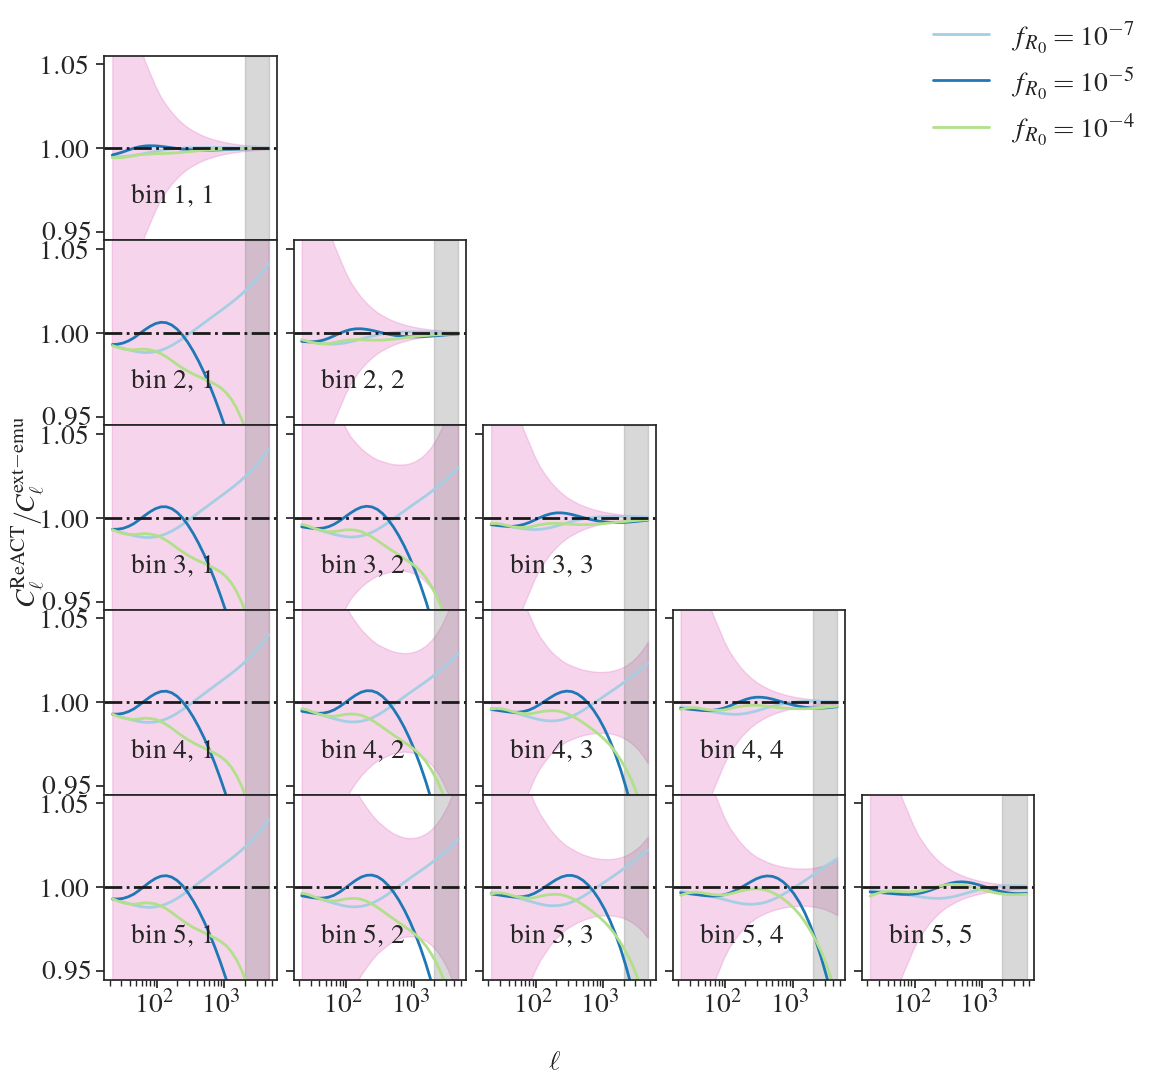

In [21]:
cell_gr_nl = ang_power_spectra_gr['GR_nonlin']['wl']
cell_gr_lin = ang_power_spectra_gr['GR_lin']['wl']
labels = ['$f_{R_0}=10^{-7}$', '$f_{R_0}=10^{-5}$', '$f_{R_0}=10^{-4}$']

fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            for num in range(len(log10f_R0_arr)):
                cl_ll_mgl = ang_power_spectra_fofr['react_nonlin'+str(num+1)]['wl']
                cl_ll_mgl_ext = ang_power_spectra_fofr['ext_nonlin'+str(num+1)]['wl']
                ax[i,j].semilogx(l_wl, cl_ll_mgl[:,i,j]/cl_ll_mgl_ext[:, i, j], linewidth=2, color = colors[num])

            cls = ang_power_spectra_fofr['ext_nonlin1']['wl']
            err_prop = err_cl_ll[:, i, j]/cls[:, i, j]
            ax[i, j].fill_between(l_wl, np.ones(len(l_wl))+err_prop, np.ones(len(l_wl))-err_prop, color='tab:pink', alpha=0.3)
            ax[i, j].set_ylim(0.945, 1.055)
            ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes) 
            ax[i, j].axhline(y=1, linestyle='-.', linewidth=2, color='k')
            ax[i, j].axvspan(xmin=l_wl_max[i, j], xmax=l_wl[-1], color='grey', alpha=0.3)
        else:
            ax[i,j].axis('off')       
fig.text(0.06, 0.5, r'$C^{\rm ReACT}_\ell/C^{\rm ext-emu}_\ell$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend(labels, loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False)